# Forecast demo
Here we load the trained Aardvark Weather model and produce a global and station forecast using the sample data. 

In [1]:
import sys
sys.path.append("../aardvark")

import pickle
import numpy as np
from e2e_model import *

import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

Check a GPU is available

In [2]:
import torch

if torch.cuda.is_available():
    print("GPU is available.")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, cannot produce forecast.")
    #torch.load(location=torch.device('cpu'))

GPU is available.
GPU name: Tesla V100-SXM2-32GB


## Generate predictions

Load the sample data (for a detailed analysis and visualisation of the contents of this dataset see data_demo.ipynb)

In [3]:
with open("../data/sample_data_final.pkl", "rb") as fp:
    data = pickle.load(fp)

/panfs/ccds02/app/modules/jupyter/ilab/dev/kernel/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.Bytes

Load the model to generate predictions at one day leadtime. First select which varaible to generate station forecasts for.

In [4]:
local_forecast_var = "tas"  # Model weights included for windspeed (ws) and 2tm (tas)

model = ConvCNPWeatherE2E(
    device="cuda",
    lead_time=1,
    se_model_path="../trained_models/encoder",
    forecast_model_path="../trained_models/processor",
    sf_model_path=f"../trained_models/decoder/{local_forecast_var}/",
    return_gridded=True,
    aux_data_path="../data/",
)

/panfs/ccds02/nobackup/projects/ilab/projects/QEFM/qefm-core/qefm/models/src/FMAardvarkWeather/aardvark-weather-public/notebooks/../aardvark/e2e_model.py:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related 

Run the model to generate a forecast the sample data. This outputs the station forecast, gridded forevast and initial state

In [5]:
station_forecast, global_forecast, initial_state = model(data)

## Visualise model predictions

First look at the gridded forecasts. Visualise several variables

In [6]:
vars = [
    "u10",
    "v10",
    "t2m",
    "mslp",
    "z200",
    "z500",
    "z700",
    "z850",
    "q200",
    "q500",
    "q700",
    "q850",
    "t200",
    "t500",
    "t700",
    "t850",
    "u200",
    "u500",
    "u700",
    "u850",
    "v200",
    "v500",
    "v700",
    "v850",
]

var_index_mapping = {k: v for v, k in enumerate(vars)}

In [7]:
lon = np.linspace(0, 359, 240)
lat = np.linspace(-90, 90, 121)

Select the variable and data to plot. To plot another variable simply change the variable argument below. 

In [8]:
variable = "u10"
var_index = var_index_mapping[variable]
initial_state_var = initial_state[0, ..., var_index].detach().cpu().numpy()
global_forecast_var = global_forecast[0, ..., var_index].detach().cpu().numpy()
colorscale_mag = np.max(np.abs(initial_state_var))

Plot the initial state

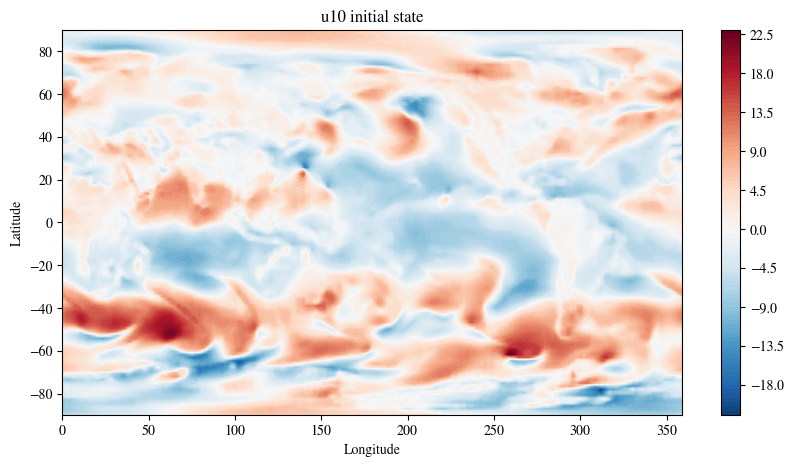

In [9]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.contourf(
    lon,
    lat,
    initial_state_var,
    levels=100,
    vmax=colorscale_mag,
    vmin=-colorscale_mag,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
# cbar.set_label('(m/s)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{variable} initial state")
plt.show()

Plot the prediction at one day leadtime

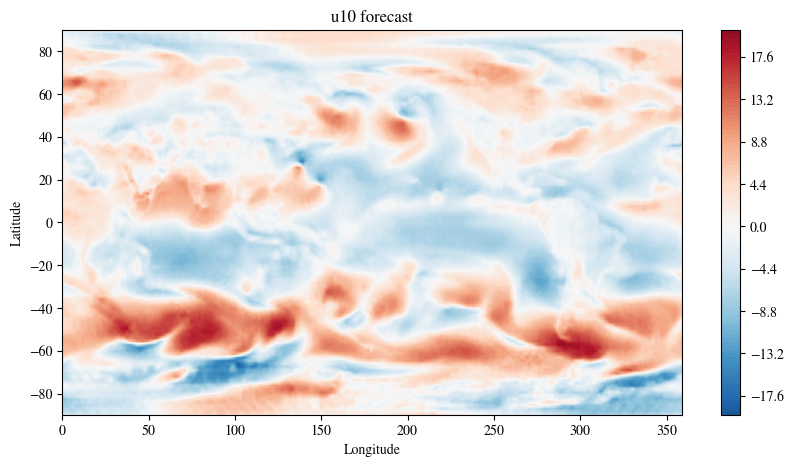

In [10]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.contourf(
    lon,
    lat,
    global_forecast_var,
    levels=100,
    vmax=colorscale_mag,
    vmin=-colorscale_mag,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
# cbar.set_label('(m/s)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{variable} forecast")
plt.show()

The model also returns the station forecasts for T2M

In [11]:
STATION_LON_LAT_SF = 360
HADISD_SCALING_FACTOR = 10
# Factors to unnormalise predictions
mean = np.load(f"../data/norm_factors/mean_hadisd_{local_forecast_var}.npy")
std = np.load(f"../data/norm_factors/std_hadisd_{local_forecast_var}.npy")

In [12]:
station_forecast = (
    station_forecast.detach().cpu() * std + mean
) * HADISD_SCALING_FACTOR

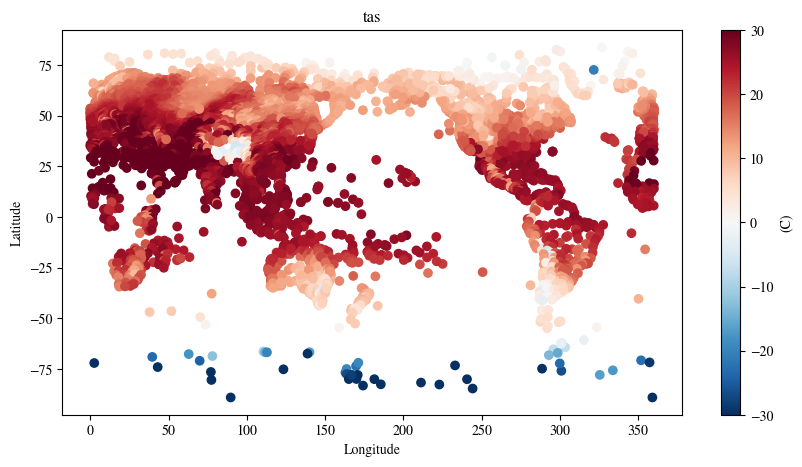

In [13]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.scatter(
    data["downscaling"]["x_target"][0, 0, :].detach().cpu() * STATION_LON_LAT_SF,
    data["downscaling"]["x_target"][0, 1, :].detach().cpu() * STATION_LON_LAT_SF,
    c=station_forecast[0, :],
    vmax=30,
    vmin=-30,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
cbar.set_label("(C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{local_forecast_var}")
plt.show()